# PHYS20762 - Project 2 - Numerical Integration of Differential Equations
# The damped harmonic oscillator

Katie Baker<br>
University of Manchester  
March 2026

First, we initialise the python interpreter.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from IPython.display import YouTubeVideo


## Introduction
This notebook will explore the use of numerical integrators to solve ODEs. In this case, we consider a horizontal simple harmonic oscillator consisting of a mass attatched to a spring. We will explore how accurately the integrators can model the system, and then alter different aspects of the system to see the physical effects.

## Defining our Values
This cell defines all of the constants used in this project. $k$ and $m$ are given where $k=0.59\, kgs^{-2}$ and $m=5.86\,kg$. From these values, we can calculate the natural frequency of the system, $\omega_0 = \sqrt{\frac{k}{m}}$, which is also unchanged throughout this project.

The values $T$, $v_0$ and $x_0$ are the total time and the initial conditions of the oscillator, respectively. These also do not change, but have been chosen out of convenience based on the constants above.

The values we will be changing in this project are $b$ and $h$, which are the damping constant and step size, respectively. The initial values $b=0.25$ and $h=0.5$ have been chosen as a way to get a rough idea of how the system behaves, in the limit of light damping (as $b < \sqrt{4km}$). After this initial inspection, we will devise a method to find the optimal value $h$, then we will consider the effects of a varying damping constant.

In [2]:
# Define constants

k = 0.59  # [kg/s**2]
m = 5.86  # [kg]

omega_0 = math.sqrt(k / m)  # Natural frequency of the system

T = 120  # [s]

# Initial conditions

v_0 = -1  # [m/s]
x_0 = 0  # [m]

# Temporary constants

b = 0.25  #[kg/s]
h = 0.5

## Numerical Integrators
Initially, we will consider a mass on a spring (with constant $k$), allowed to oscillate without an external driving force. The mass experiences a damping force proportional to its velocity, with a drag constant $b$. The equation of motion is as follows:
$$ m \ddot x = -k x -b \dot x.$$
This is rearranged to give:
$$ \ddot x + \gamma \dot x + \omega_0^2 x = 0,$$
where $\omega_0 = \frac {k}{m}$ is the natural frequency and  $\gamma = \frac {b}{m}$ is the damping ratio. This second order ODE can be solved analytically, but also numerically.

Subject to the initial conditions $x(0)=0\: m$ and $\dot x(0)=-1 \:ms^{-1}$, the four methods we will be considering are as follows:


**Euler's method**
<br>
The first of the four methods. $x$, $v$ and $a$ are found iteratively: $x_{i+1} = x_i + h v_i$,  $v_{i+1} = v_i + h a_i$ and $a_i = -\omega_0^2 x_i - \gamma v_i$.
<br>

**Improved Euler's method**
 <br>
This method is identical to the first, except it increases its accuracy by including another term in the expression for $x$. The expression for $x_{i+1}$ is now given by <br>
$x_{i+1} = x_i + h v_i + \frac {h^2}{2} a_i$, with the expressions for velocity and acceleration remaining the same.

**Verlet's Method**
<br>
This method is more complicated, and comes from using an extra term in the Taylor expansion used to derive Euler's method (not discussed here): $x_{i+1} = Ax_i + Bx_{i-1}$ where $A = \frac {2(2m - kh^2)}{D}$, $B = \frac {bh - 2m}{D}$ and $D = 2m + bh$. The velocity is given by $v_i = \frac{x_{i+1} - x_{i-1}}{2 * h}$.

**Cromer's Method**
<br>
We can make a small adjustment to Euler's method to obtain the following: $x_{i+1} = x_i + hv_{i+1}$, and the expressions for acceleration and velocity are the same as with the original Euler's method.

In [3]:
def euler(h, steps):
    """Function defining Euler's method for finding x and v. Returns x and v."""

    # Creates intial array of zeros
    
    x = np.zeros((steps))
    v = np.zeros((steps))

    x[0], v[0] = x_0, v_0
    
    # Euler's method

    for i in range(steps-1):
        a = -(omega_0**2) * x[i] - (b/m) * v[i]
        v[i+1] = v[i] + h * a
        x[i+1] = x[i] + h * v[i]

    return x, v


def improved_euler(h, steps):
    """Function defining the Improved Euler's method for finding x and v. Returns x and v."""

    # Creates initial array of zeros

    x = np.zeros((steps))
    v = np.zeros((steps))

    x[0], v[0] = x_0, v_0
    
    # Improved Euler method

    for i in range(steps - 1):
        a = -(omega_0**2) * x[i] - (b/m) * v[i]  
        v[i+1] = v[i] + h * a
        x[i+1] = x[i] + h * v[i] + ((h**2) / 2) * a

    return x, v



def verlet(h, first_step, steps):
    """Function defining Verlet's method for finding x and v. This method is not self-starting, so requires an initial value of x and v from another method. Returns x and v."""

    # Creates initial array of zeros

    x = np.zeros((steps))
    v = np.zeros((steps))

    # Initial x, first step from imporved euler method

    x[0], v[0] = x_0, v_0
    x[1], v[1] = first_step[0], first_step[1]

    D = 2 * m + b * h
    B = (h * b - 2 * m) / D
    A = 2 * (2 * m - k * h**2) / D

    # Verlet's method iterating from index=1 onwards

    for i in range(1, steps -1):
        x[i+1] = A * x[i] + B * x[i-1]
        v[i] = (x[i+1] - x[i-1]) / (2 * h)

    return x, v


def cromer(h, steps, b):
    """Function defining Cromer's method for finding x and v. Returns x and v."""

    # Creates intial array of zeros

    x = np.zeros((steps))
    v = np.zeros((steps))

    x[0], v[0] = x_0, v_0

    # Euler-Cromer method

    for i in range(0, steps-1):
        a = -(omega_0**2) * x[i] - (b/m) * v[i]
        v[i+1] = v[i] + h * a
        x[i+1] = x[i] + h * v[i+1]

    return x, v


def analytical_light(t, b):
    """The analytical solution for the displacement of the mass, in the case of light damping. Returns x at a given time."""

    gamma = b / m
    omega_d = math.sqrt(omega_0**2 - (gamma**2 / 4))

    x = - np.exp(- gamma * t / 2) * np.sin(omega_d * t) / omega_d

    return x

def analytical_velocity_light(t, b):
    """The analytical solution for the velocity of the mass, in the case of light damping. Returns v at a given time."""
    
    gamma = b / m
    omega_d = math.sqrt(omega_0**2 - (gamma**2 / 4))
    
    v = np.exp(-gamma * t / 2) * ((gamma / (2 * omega_d)) *np.sin(omega_d * t) - np.cos(omega_d * t))

    return v

steps = int(T / h)  # Total number of steps

x_euler, v_euler = euler(h, steps)
x_impeuler,v_impeuler = improved_euler(h, steps)

first_step = x_impeuler[1], v_impeuler[1]  # Defines the first step for use in verlet method

x_verlet, v_verlet = verlet(h, first_step, steps)
x_cromer, v_cromer = cromer(h, steps, b)

x_arrays = x_euler, x_impeuler, x_verlet, x_cromer
v_arrays = v_euler, v_impeuler, v_verlet, v_cromer



## Visualising Numerical Integrators
This cell plots the numerical solutions against the analytical solution. This can be used to visualise the errors of each method by showing how the numerical solutions vary from the analytical solution. There are two plots, one for displacement against time and one for displacement against velocity (known as phase space). A phase space plot may be useful as it shows all possible physical states which a system can be in. The time plot shows how the oscillations evolve with time.

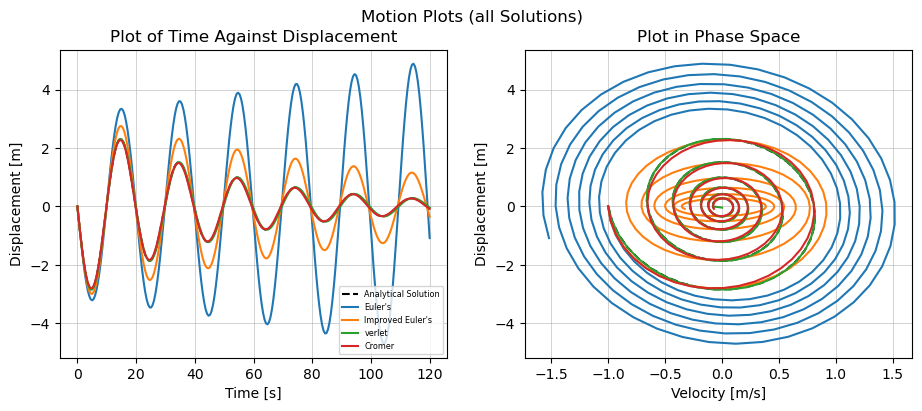

<Figure size 640x480 with 0 Axes>

In [4]:
def displacement_plot():
    """For plotting analytical solutions and numerical solutions."""
    
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Displacement against time
    
    axes[0].plot(t, x_analytical, label='Analytical Solution', linestyle='--', color='k')
    axes[0].plot(t, x_euler, label="Euler's")
    axes[0].plot(t, x_impeuler, label="Improved Euler's")
    axes[0].plot(t, x_verlet, label='verlet')
    axes[0].plot(t, x_cromer, label='Cromer')
    axes[0].set_title('Plot of Time Against Displacement')
    axes[0].set_xlabel('Time [s]')
    axes[0].set_ylabel('Displacement [m]')
    axes[0].legend(fontsize='xx-small', loc=4)
    axes[0].grid(linewidth=0.4)

    # Phase space plot

    axes[1].plot(v_analytical, x_analytical, label='Analytical Solution', linestyle='--', color='k')
    axes[1].plot(v_euler, x_euler, label='Eulers')
    axes[1].plot(v_impeuler, x_cromer, label='Improved Euler')
    axes[1].plot(v_verlet, x_verlet, label='Verlet')
    axes[1].plot(v_cromer, x_cromer, label='Cromer')
    axes[1].set_title('Plot in Phase Space')
    axes[1].set_xlabel('Velocity [m/s]')
    axes[1].set_ylabel('Displacement [m]')
    axes[1].grid(linewidth=0.4)

    fig.suptitle('Motion Plots (all Solutions)')
    plt.show()
    plt.tight_layout()

# Defines the time values for plotting

t = np.linspace(0, T , steps)

# Arrays of the x and v values for the analytical solution

x_analytical = analytical_light(t, b)
v_analytical = analytical_velocity_light(t, b)

displacement_plot()



We see on the left-hand plot, as t increases, both Euler's and Improved Euler's method increasingly deviate from the alalytical solution, implying an increase in the energy of the oscillator. With no driving force, this isn't physically possible, so must be a result of the numerical methods used. This is also shown in the phase space plot, where their phase plots are almost completely different to the analytical solution. From this, we can say that these two methods are inaccurate and cannot competently model this system.

## Classifying and Visualising Errors
We will initially visualise the (discretisation) errors directly by finding the error at each point, given by
$$error = |X_{analytical} - X_{numerical}|,$$

the absolute value of the difference between the analytical solution and the numerical solutions at each point. For the value of $h=0.5$ defined above, we will plot these errors and see how they evolve with time.

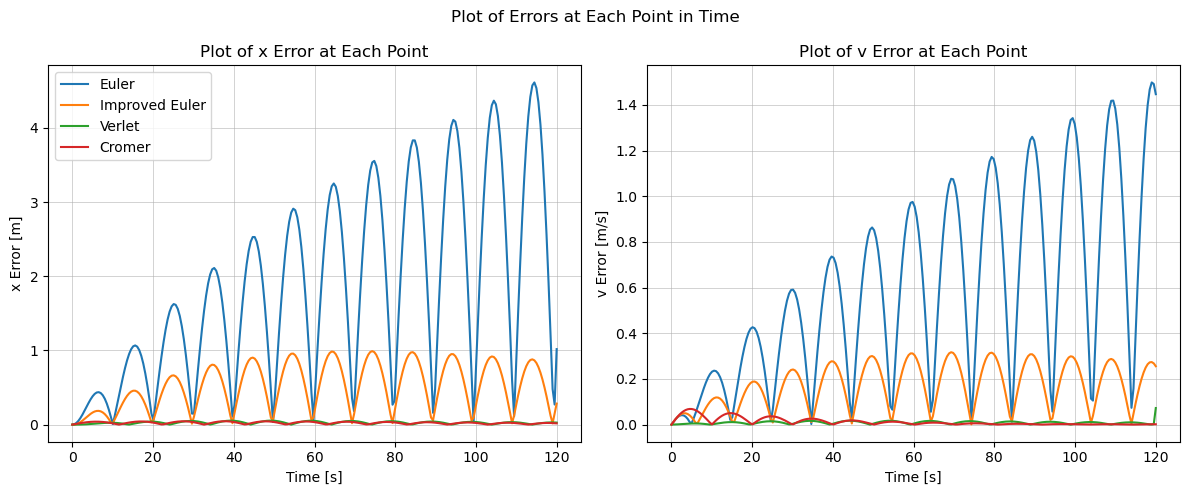

In [5]:
def error_plot():
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

    x_errors = []  # Defines empty list, will contain 4 arrays of errors in the order Euler, Improved Euler, Verlet and Cromer
    for x in x_arrays:
        error = np.abs(x_analytical - x)
        x_errors.append(error)

    v_errors = []  # Similar to previous comment, but for velocity
    for v in v_arrays:
        error = np.abs(v_analytical - v)
        v_errors.append(error)

    # Plots errors in displacement

    ax1.plot(t, x_errors[0], label='Euler')
    ax1.plot(t, x_errors[1], label='Improved Euler')
    ax1.plot(t, x_errors[2], label='Verlet')
    ax1.plot(t, x_errors[3], label='Cromer')
    ax1.set_title('Plot of x Error at Each Point')
    ax1.set_xlabel('Time [s]')
    ax1.set_ylabel('x Error [m]')
    ax1.grid(linewidth=0.4)
    ax1.legend()

    # Plots errors in velocity

    ax2.plot(t, v_errors[0], label='Euler')
    ax2.plot(t, v_errors[1], label='Improved Euler')
    ax2.plot(t, v_errors[2], label='Verlet')
    ax2.plot(t, v_errors[3], label='Cromer')
    ax2.set_title('Plot of v Error at Each Point')
    ax2.set_xlabel('Time [s]')
    ax2.set_ylabel('v Error [m/s]')
    ax2.grid(linewidth=0.4)

    fig.suptitle('Plot of Errors at Each Point in Time')
    plt.tight_layout()
    plt.show()
    
error_plot()

As expected, the maximum error in displacement for both the Euler and Improved Euler methods increases with time. Their errors in the first oscillation are also much greater than for the other two methods, showing their inaccuracy. There is a similar trend for the error in velocity, though the initial errors are actually lower than for Verlet (though quickly become larger).

The errors for Verlet and Cromer are both much smaller, making them hard to differentiate in this plot, showing how they are the much more accurate methods.

## Choosing h: Error Minimisation

We will expand on our error analysis from the previous section. Here, we will vary $h$, and compare the errors at a set point in time. As accuracy increases (for all methods) with decreasing $h$, we choose our largest value of $h$ to be 0.05s. As the number of steps is related to the time by $\;t = h \times n_{steps}$, we pick a value of $t$ which is a multiple of 0.05, and then halve $h$ until we cover a decade. By doing this, we can ensure we are making a direct comparason of errors at the exact same point for each value of $h$ (avoids computing error from rounding steps).

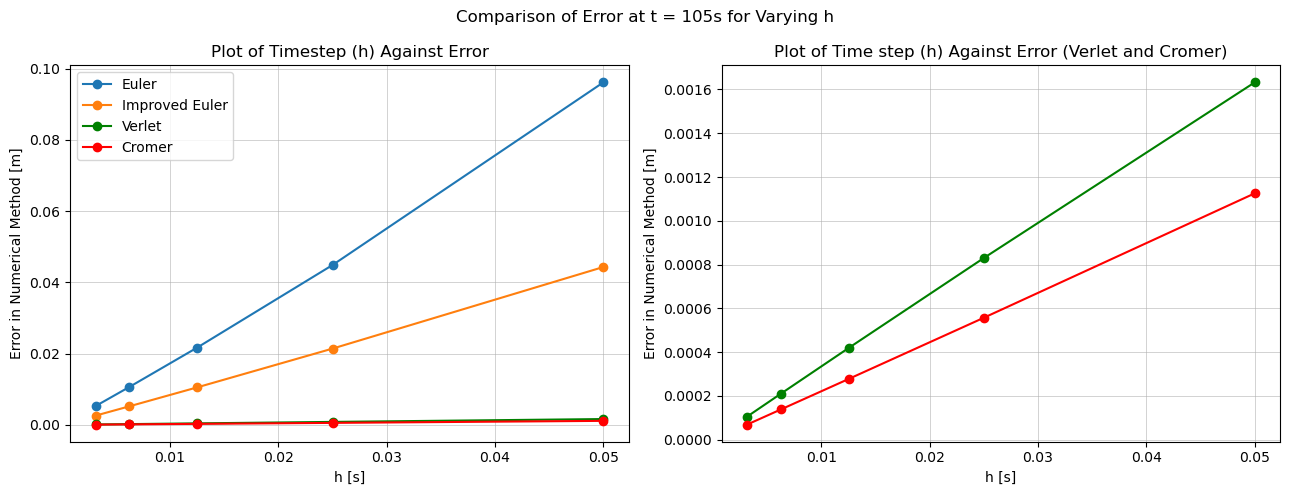

In [6]:
def numerical_error(h, t, first_step, steps):

    # Finds the error in each method at t = 105 s

    euler_error = np.abs(analytical_light(t, b) - euler(h, steps)[0][steps - 1])
    impeuler_error = np.abs(analytical_light(t, b) - improved_euler(h, steps)[0][steps - 1])
    verlet_error = np.abs(analytical_light(t, b) - verlet(h, first_step, steps)[0][steps - 1])
    cromer_error = np.abs(analytical_light(t, b) - cromer(h, steps, b)[0][steps - 1])

    return euler_error, impeuler_error, verlet_error, cromer_error

def all_error_plot():

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))

    # Plots the error in all methods gainst h

    ax1.plot(h_values, euler_error_values, marker='o', label='Euler')
    ax1.plot(h_values, impeuler_error_values, marker='o', label='Improved Euler')
    ax1.plot(h_values, verlet_error_values, color='g', marker='o', label='Verlet')
    ax1.plot(h_values, cromer_error_values, color='r', marker='o', label='Cromer')
    ax1.set_xlabel('h [s]')
    ax1.set_ylabel('Error in Numerical Method [m]')
    ax1.set_title('Plot of Timestep (h) Against Error')
    ax1.grid(linewidth=0.4)
    ax1.legend()
    
    # Plots only the verlet and cromer method

    ax2.plot(h_values, verlet_error_values, color='g', marker='o', label='Verlet')
    ax2.plot(h_values, cromer_error_values, color='r', marker='o', label='Cromer')
    ax2.set_xlabel('h [s]')
    ax2.set_ylabel('Error in Numerical Method [m]')
    ax2.set_title('Plot of Time step (h) Against Error (Verlet and Cromer)')
    ax2.grid(linewidth=0.4)

    fig.suptitle('Comparison of Error at t = 105s for Varying h')
    plt.tight_layout()
    plt.show()
    
# Values of h, by halfing from 0.05 down to 0.003125

h_values = np.array([0.003125, 0.00625, 0.0125, 0.025, 0.05])

# Empty lists to append the error values to

euler_error_values = []
impeuler_error_values = []
verlet_error_values = []
cromer_error_values = []

# Iterates over all of the values for h

for h in h_values:
    t_error = 105
    steps_fixed_time = int(t_error / h)  # Will always be a whole number
    impeuler_arrays = improved_euler(h, steps_fixed_time)  # x and v arrays
    first_step = impeuler_arrays[0][1], impeuler_arrays[1][1]

    # Finds the error for each method

    euler_error, impeuler_error, verlet_error, cromer_error = numerical_error(h,t_error, first_step, steps_fixed_time)

    # Appends the max error to the lists above

    euler_error_values.append(euler_error)
    impeuler_error_values.append(impeuler_error)
    verlet_error_values.append(verlet_error)
    cromer_error_values.append(cromer_error)


all_error_plot()

As previously discussed, the errors in Euler's and Improved Euler's method are significantly larger at all values of $h$. We will no longer consider either of these to be our method of choice. When considering the right-hand plot, we can also see that the error in Verlet's method is increasingly larger than for Cromer's method. This is less apparent for lower values of $h$, but is still present.

From our analysis, we can see that our best method for modelling this system is Cromer's method. This will be the method used for the following sections. We will use the value $h = 0.005 s$ from now onwards also. This value is sufficiently low so that the method is accurate, but not so low that the number of steps is great enough to be time inefficient.

## Types of Damping
Using Cromer's method, we will now consider how this system behaves with different values of the damping term, $b$. We consider three situations:
$ b\, = \,\frac{1}{2} b_{crit}, \; b = b_{crit}\,$ and $\, b = 2 b_{crit}$ where $b_{crit}\, =\, \sqrt{2km}$ and is the value of $b$ where the mass returns to equilibrium fastest, without oscillating.

In terms of the quality factor $Q = \frac {\omega_0}{\gamma}$, the ratio to energy stored to energy lost per oscillation, we can say that:

$\cdot$ for $b > b_{crit}$, $Q < \frac{1}{2}$ and the system is overdamped
<br>
$\cdot$ for $b < b_{crit}$, $Q > \frac{1}{2}$ and the system is underdamped
<br>
$\cdot$ for $b = b_{crit}$, $Q = \frac{1}{2}$ and the system is critically damped

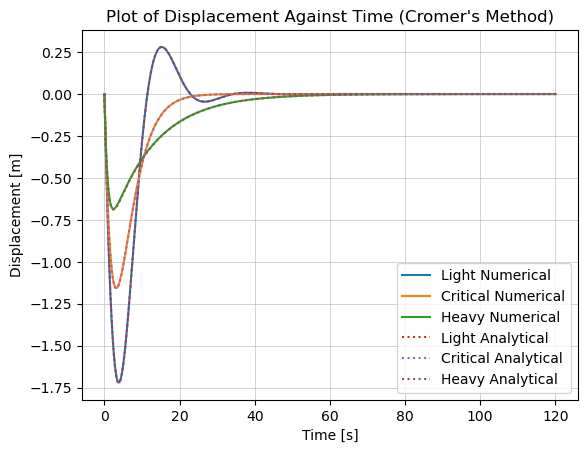

In [7]:
def heavy_damping(t, b):
    'The analytical solution for heavy damping/ over-damped system.'

    gamma = b / m
    alpha = math.sqrt((gamma**2 / 4)- omega_0**2)

    x = (-1 / alpha) * np.exp((-gamma / 2) * t) * np.sinh(alpha * t)

    return x

def critical_damping(t, b):
    'The analytical solution for critical damping.'

    gamma = b / m
  
    x = -t * np.exp(-gamma/2 * t)

    return x

def damping_plot(h, b_values):

    # Numerical solution

    plt.plot(t, cromer(h, steps, b_values[0])[0], label='Light Numerical')
    plt.plot(t, cromer(h, steps, b_values[1])[0], label='Critical Numerical')
    plt.plot(t, cromer(h, steps, b_values[2])[0], label='Heavy Numerical')

    # Analytical solutions

    plt.plot(t, analytical_light(t, b_values[0]), linestyle=':', label='Light Analytical')
    plt.plot(t, critical_damping(t, b_values[1]), linestyle=':', label='Critical Analytical')
    plt.plot(t, heavy_damping(t, b_values[2]), linestyle=':', label='Heavy Analytical')

    plt.xlabel('Time [s]')
    plt.ylabel('Displacement [m]')
    plt.title("Plot of Displacement Against Time (Cromer's Method)")
    plt.grid(linewidth=0.4)
    plt.legend()
    plt.show()

# Redefines the step size, the number of steps and the time values (used in plotting)

h = 0.005
steps = int(T / h)
t = np.linspace(0, T , steps)

# Defines the damping constant values

b_crit = math.sqrt(4 * k * m)
b_values = np.array([0.5 * b_crit, b_crit, 2 * b_crit])

damping_plot(h, b_values)

As expected, our numerical solutions match the analytical solutions, showing how our chosen integrator (Cromer) maintains its accuracy even when varying different aspects of the system. Looking at the plot, we see how the different values of $b$ correspond to light/ under damping, critical damping and heavy/ over damping (the slashed terms can be used interchangibly in our case). Light damping is the only type of damping that shows oscillatory behaviour, where the oscillations now occur at the damping frequency $\omega_d^2 = \omega_0^2 - \frac{\gamma^2}{4}$. Both critical and heavy damping show no oscillations, with critical damping returning to the equilibrium in the fastest possible time.

## Sudden Push
Previously, we have only considered completely undriven motion, i.e. no external 'pushing' force. Now, we will consider the effect of a small 'push' to the system at different points in the oscillations and in different directions relative to the velocity. Our 'push' is an impulse force which follows a Gaussian distribution, varying with time:

$$F = F_{peak}\exp\left(-\frac {(t - t_{push})^2}{2\sigma^2}\right)$$

 The Gaussian is centred at the push time, meaning the maximum force is delivered at the time of the push, which trails off before and after this specified time. $\sigma$ is a parameter which affects the width of the distribution, the physical meaning of which is how instantaneous the push is. This mimics what would happen in a realistic physical system, where the force isn't actually instantaneous, but applied over a short (but finite) period of time.

 *Note: the maximum force and the width can be edited in the code cell by changing the values for FORCE_PEAK ($F_{peak}$) and WIDTH ($\sigma$).*


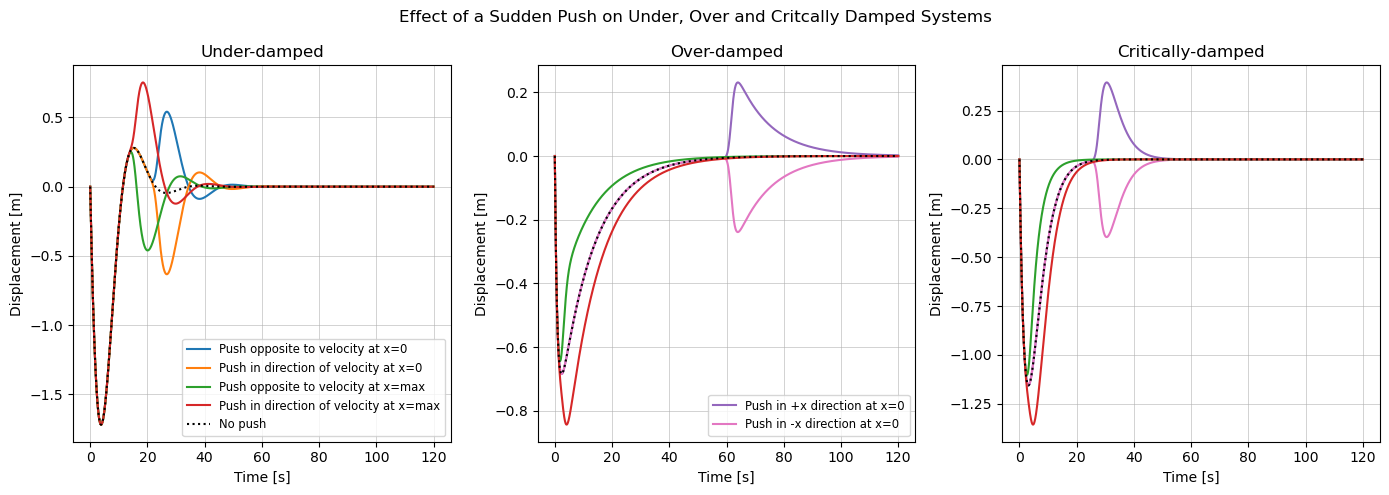

In [8]:
# Customisable push parameters

FORCE_PEAK = 1  # By default, 1 N
WIDTH = np.pi / (12 * omega_0)  # WIDTH = sigma. By default, 1/24 of the natural time period: Period = 2π / ω_0. 

def cromer_push(steps, push_direction, gamma, push_step):

    # Creates intial array of zeros

    x = np.zeros((steps))
    v = np.zeros((steps))

    # Inital parameters

    x[0], v[0] = x_0, v_0

    # Euler-cromer method

    for i in range(steps-1):
        
        push_force = push_direction * gaussian_push(t[i], push_step, FORCE_PEAK, WIDTH)

        a = -(omega_0**2) * x[i] - (gamma) * v[i] + push_force / m

        v[i+1] = v[i] + h * a
        x[i+1] = x[i] + h * v[i+1]

    return x, v

def push_plot():

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    # Light damping

    gamma_light = b_values[0] / m
    axes[0].plot(t, cromer_push(steps, 1, gamma_light, light_root_index)[0], label='Push opposite to velocity at x=0')
    axes[0].plot(t, cromer_push(steps, -1, gamma_light, light_root_index)[0], label='Push in direction of velocity at x=0')
    axes[0].plot(t, cromer_push(steps, -1, gamma_light, light_max_index)[0], label='Push opposite to velocity at x=max')
    axes[0].plot(t, cromer_push(steps, 1, gamma_light, light_max_index)[0], label='Push in direction of velocity at x=max')
    axes[0].plot(t, cromer_push(steps, 0, gamma_light, 1)[0], ':k', label='No push')
    axes[0].set_title('Under-damped')
    axes[0].legend(fontsize='small', loc=4)

    # Heavy damping

    gamma_heavy = b_values[2] / m
    axes[1].plot(t, cromer_push(steps, 1, gamma_heavy, heavy_root_index)[0], c='C4', label='Push in +x direction at x=0')
    axes[1].plot(t, cromer_push(steps, -1, gamma_heavy, heavy_root_index)[0], c='C6', label='Push in -x direction at x=0')
    axes[1].plot(t, cromer_push(steps, 1, gamma_heavy, heavy_max_index)[0], c='C2')  # Push opposite to velocity at x=max
    axes[1].plot(t, cromer_push(steps, -1, gamma_heavy, heavy_max_index)[0], c='C3')  #Push in direction to velocity at x=max
    axes[1].plot(t, cromer_push(steps, 0, gamma_heavy, 1)[0], ':k')
    axes[1].set_title('Over-damped')
    axes[1].legend(fontsize='small', loc=4)
    
    # Critical damping

    gamma_crit = b_values[1] / m
    axes[2].plot(t, cromer_push(steps, 1, gamma_crit, crit_root_index)[0], c='C4', label='Push +x direction at x=0')
    axes[2].plot(t, cromer_push(steps, -1, gamma_crit, crit_root_index)[0], c='C6', label='Push in -x direction at x=0')
    axes[2].plot(t, cromer_push(steps, 1, gamma_crit, crit_max_index)[0], c='C2')  # Push opposite to velocity at x=max
    axes[2].plot(t, cromer_push(steps, -1, gamma_crit, crit_max_index)[0], c='C3')  #Push in direction to velocity at x=max
    axes[2].plot(t, cromer_push(steps, 0, gamma_crit, 1)[0], ':k', label='No push')
    axes[2].set_title('Critically-damped')

    for ax in axes:
        ax.set_xlabel('Time [s]')
        ax.set_ylabel('Displacement [m]')
        ax.grid(linewidth=0.4)

    fig.suptitle('Effect of a Sudden Push on Under, Over and Critcally Damped Systems')
    plt.tight_layout()
    plt.show()

def gaussian_push(t, push_step, force_peak, width):
    '''The push force, modelled as a gaussian. The force peaks at the push time, with a max amplitude given by FORCE_PEAK and a 'duration' given by WIDTH.'''

    push_peak_time = push_step * h  # Defines the time where the 'push' is said to occur

    gaussian_push = force_peak * np.exp(-(t- push_peak_time)**2 / (2 * width**2))

    return gaussian_push

# Un-pushed displacement values

disp_values_light = cromer(h, steps, b_values[0])[0]
disp_values_crit = cromer(h, steps, b_values[1])[0]
disp_values_heavy = cromer(h, steps, b_values[2])[0]

light_max_index = np.argmax(disp_values_light)
crit_max_index = np.argmax(np.abs(disp_values_crit))
heavy_max_index = np.argmax(np.abs(disp_values_heavy))

# Initially none, but will be replaced with the indeces of the 'roots' of each damping type

light_root_index = None
crit_root_index = None
heavy_root_index = None

# Finds the third root for light damping by comparing signs of consecutive values for indeces above the first maxima

for i in range(light_max_index, len(disp_values_light)-1):
    if np.sign(disp_values_light[i]) != np.sign(disp_values_light[i+1]) and light_root_index is None:
        light_root_index = i
        break

# Finds the first index where |displacement| falls less than 0.005m for the other damping methods (x never truly reaches 0)

for i in range(crit_max_index, len(disp_values_crit)-1):
    if disp_values_crit[i] > -0.005 and crit_root_index is None:
        crit_root_index = i

    if disp_values_heavy[i] > -0.005 and heavy_root_index is None:
        heavy_root_index = i
    
    if crit_root_index is not None and heavy_root_index is not None:
        break

push_plot()

For simplicity, we shall refer to a push in the direction of motion as 'case 1', and a push in the opposing direction as 'case 2'.

Starting with the under-damped plot, we can see that the change in amplitude of the curve is different depending on the timing and direction. When the force is applied at the maximum displacement for case 1, the amplitude of the resultant displacementis greater than when applied in case 2. This would make sense, since the former *adds* energy to the system, rather than removing it as seen by 

$$\Delta E = \int_{t_1}^{t_2}\mathbf{v \cdot F}.$$

When the impulse force is applied at zero displacement, there is a similar effect, though the change in amplitude seems to be even more apparent. This is due to the fact that the greatest energy transfer occurs when the velocity is the greatest, which occurs at $x = 0$.


The effect may be easier to see on the other two plots; for case 1, the change in the amplitude is much greater than for case 2, where the maximum displacement only slightly differs from the unpushed oscillator. For heavy damping, case 2 causes a much faster velocity towards equilibrium than the alternative. The mass would seem to return to equilibrium much faster than in case 1. Interestingly, this isn't the case for critical damping, where the return to equilibrium seems to happen at the same rate for both. Given that critical damping is when the mass decays back to its equilibrium position in the fastest time (no matter the previous motion of the system), it follows that the return velocities would be similar.

When the heavy and critically damped systems are pushed after returning to equilibrium, there is symmetric motion in either direction. The explanation for this is trivial, and is simply due to the lack of initial velocity at this point.

## Application of a Sinusoidal Driving Force
Expanding on the previous section, we now consider a sinusoidal driving force of the form

$$F(\omega) = F_0 \cos{\omega t},$$

which is applied continously, rather than at one specific time. This force will have a frequency ($\omega$) different to the natural and damped frequency. We consider the case where $\omega = 2 \omega_0$.

*Note: the maximum force can be edited in the code cell by changing the value for F_0.*

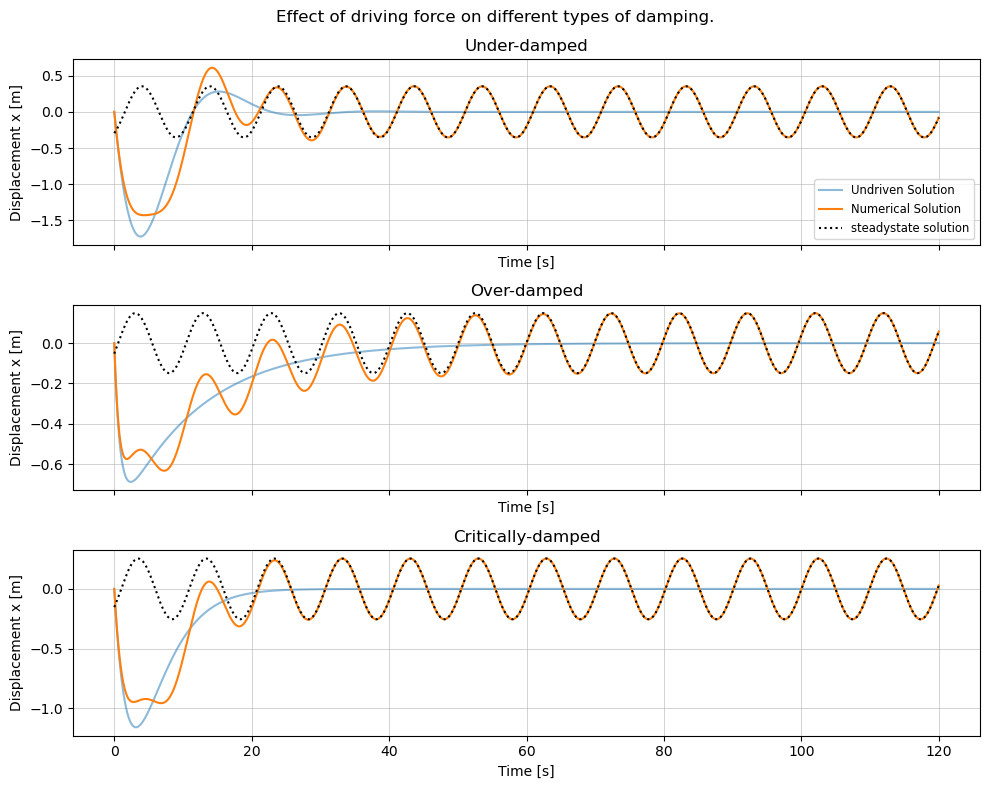

In [9]:
# Customisable driving force amplitude. By default, 0.75N

F_0 = 0.75

def cromer_driven(steps, F_0, gamma, omega):

    # Creates intial array of zeros

    x = np.zeros((steps))
    v = np.zeros((steps))

    # Inital parameters

    x[0], v[0] = x_0, v_0

    # Euler-cromer method with added sinusoidal term from driving force

    for i in range(steps-1):
        a = -(omega_0**2) * x[i] - (gamma) * v[i] + (F_0 / m) * np.cos(omega * t[i])
        v[i+1] = v[i] + h * a
        x[i+1] = x[i] + h * v[i+1]
    
    return x, v

def damped_driven_steadystate(t, amplitude, omega, delta):
    'The analytical solution after transients dies down and the system oscillates at the driving frequency.'

    x = amplitude * np.cos(omega * t - delta)

    return x

def amplitude_Response(omega, gamma):
    'The amplitude response funtion.'

    numerator = F_0 / m
    demonimator = np.sqrt((omega_0**2 - omega**2)**2 + omega**2 * gamma**2)

    return (numerator / demonimator)

def phase_angle(omega, gamma):
    'Function which defines the phase angle (gamma) at a given driving frequency.'

    numerator = gamma * omega
    denominator = omega_0**2 - omega**2

    delta = np.arctan2(numerator, denominator)

    return delta

def driven_plot(amplitudes, phases, gamma, omega):

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    
    # Light damping

    axes[0].plot(t, analytical_light(t, b_values[0]), alpha=0.5, label='Undriven Solution')
    axes[0].plot(t, cromer_driven(steps, F_0, gamma[0], omega)[0], label='Numerical Solution')
    axes[0].plot(t, damped_driven_steadystate(t, amplitudes[0], omega, phases[0]), label='steadystate solution', color='k', linestyle=':')
    axes[0].set_title('Under-damped')
    axes[0].legend(loc=4, fontsize='small')

    # Heavy damping

    axes[1].plot(t, heavy_damping(t, b_values[2]), alpha=0.5, label='Undriven Solution')
    axes[1].plot(t, cromer_driven(steps, F_0, gamma[2], omega)[0], label='Numerical Solution')
    axes[1].plot(t, damped_driven_steadystate(t, amplitudes[2], omega, phases[2]), label='steadystate solution', color='k', linestyle=':')
    axes[1].set_title('Over-damped')

    # Critical damping

    axes[2].plot(t, critical_damping(t, b_values[1]), alpha=0.5, label='Undriven Solution')
    axes[2].plot(t, cromer_driven(steps, F_0, gamma[1], omega)[0], label='Numerical Solution')
    axes[2].plot(t, damped_driven_steadystate(t, amplitudes[1], omega, phases[1]), label='steadystate solution', color='k', linestyle=':')
    axes[2].set_title('Critically-damped')

    for ax in axes:
        ax.set_xlabel("Time [s]")
        ax.set_ylabel("Displacement x [m]")
        ax.grid(linewidth=0.4)

    fig.suptitle('Effect of driving force on different types of damping.')
    fig.tight_layout()
    plt.show()  


gamma_values = b_values / m 
omega_driven = 2 * omega_0

amplitude_values = amplitude_Response(omega_driven, gamma_values)
phase_values = phase_angle(omega_driven, gamma_values)

driven_plot(amplitude_values, phase_values, gamma_values, omega_driven)


For all three plots, there is an initial period when the force is applied where the numerical solutions shows erratic behaviour in its oscillations, called the transient responce (or just transients). Over time, this behaviour subsides, and the system settles into uniform oscillations at the given driving frequency (the steady state condition).
 
As the magnitude of the driving force decreases (i.e. F_0 is lower), the oscillations become closer to the original, un-driven oscillations. Depending on the ratio of the magnitudes of the intrinsic oscillator forces and the driving force, one may dominate. A smaller driving force will cause the transients to closely mirror the un-pushed displacement, and will take longer to settle into the steady state condition of reduced amplitude.

One interesting aspect of this plot is that it shows how quickly each type of damping will settle into its driven oscillations. Once again, the critically damped system falls into the steady state condition the fastest; the importance of this will be highlighted in a later section.

## Phase Angle
Something we haven't explicitly mentioned before is the solution for damped, forced oscillations. This is given by

$$x(t) = A(\omega)cos(\omega t - \delta)$$

The phase angle, $\delta$, is different to the typical $\phi$ we see in solutions, which relates to the initial conditions. $\delta$ relates to the phase angle between the driving force and the displacement and is given by

$$\tan{\delta} = \frac {\omega \gamma}{(\omega_0^2 - \omega^2)}.$$


The negative sign implies the displacement drags behind our driving force. Like the amplitude, this also changes with $\omega$.

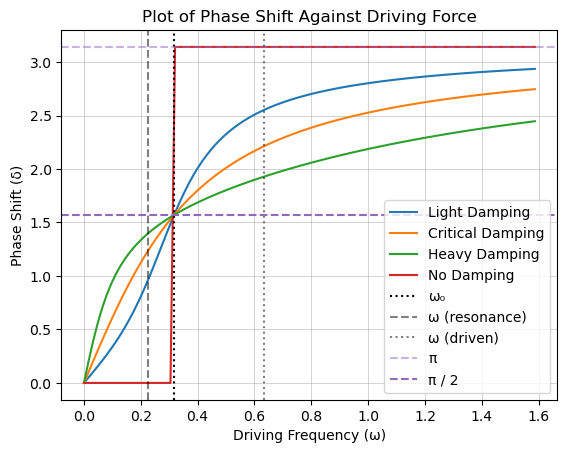

In [10]:
def phase_plot():

    plt.plot(omega_cont, phase_angle(omega_cont, gamma_values[0]), label='Light Damping')
    plt.plot(omega_cont, phase_angle(omega_cont, gamma_values[1]), label='Critical Damping')
    plt.plot(omega_cont, phase_angle(omega_cont, gamma_values[2]), label='Heavy Damping')
    plt.plot(omega_cont, phase_angle(omega_cont, 0), label='No Damping')
    plt.axvline(omega_0, linestyle=":", color='k', label="ω₀")
    plt.axvline(omega_res, linestyle="--", color='k', alpha=0.5, label="ω (resonance)")
    plt.axvline(omega_driven, linestyle=":", color='k', alpha=0.5, label="ω (driven)")
    plt.axhline(np.pi, linestyle="--", color='C4', alpha=0.5, label="π")
    plt.axhline(np.pi / 2, linestyle="--", color='C4', label="π / 2")
    plt.title('Plot of Phase Shift Against Driving Force')
    plt.xlabel('Driving Frequency (ω)')
    plt.ylabel('Phase Shift (δ)')
    plt.grid(linewidth=0.4)
    plt.legend()
    plt.show()

omega_cont = np.linspace(0, 5 * omega_0, 100)
omega_res = np.sqrt(omega_0**2 - gamma_values[0]**2 / 2)  # Resonant frequency

phase_plot()

Starting with the simplest case of no damping, the phase angle will take a value of either $\pi$ for $\omega > \omega_0$ or 0 for $\omega < \omega_0$. When the driving frequency is relatively small, the driving force and displacement are in phase with one another. When it is larger than the natural frequency, the driving force and displacement are in anti-phase.

When we begin to consider damping, we see that for all types, $\delta = \frac {\pi}{2}$ when $\omega = \omega_0$, and tends to $\pi$ as $\omega \rightarrow \infty$. For a harmonic oscillator, the displacement always lags behind the velocity by $\frac {\pi}{2}$, this leads to the conclusion that at the natural frequency, the mass is always moving in the direction of the driving force. But as we will see in the next section, damped, forced systems don't resonate at $\omega = \omega_0$. For light damping, $\omega_{res}$ is slightly less than $\omega_0$, so the phase angle at resonance actually ends up being considerably lower by about a third (see plot). 

The main difference between the types of damping is how sensitively they react to a change in driving frequency. When $\omega < \omega_0$, systems with larger damping react more sensitively, their phase angle will increase rapidly until $\omega = \omega_0$. Past this point, we see the opposite trend, where systems with larger damping are now less sensitive to changes in frequency.

## Amplitude Response and Resonance
When forcing oscillations, it is important to consider the frequency of the driving force. For our sinusoidal driving force, we arbitrarily used a frequency of $\omega = 2 \omega_0$. But what would happen if we were to increase or decrease this? For forced, damped oscillations, we find the amplitude response function to be

$$A(\omega) = \frac{F_0 / m}{\sqrt{(\omega_0^2 - \omega^2)^2 + \omega^2\gamma^2}}.$$




This section will explore the effect of driving frequency on the maximum amplitude of a system.


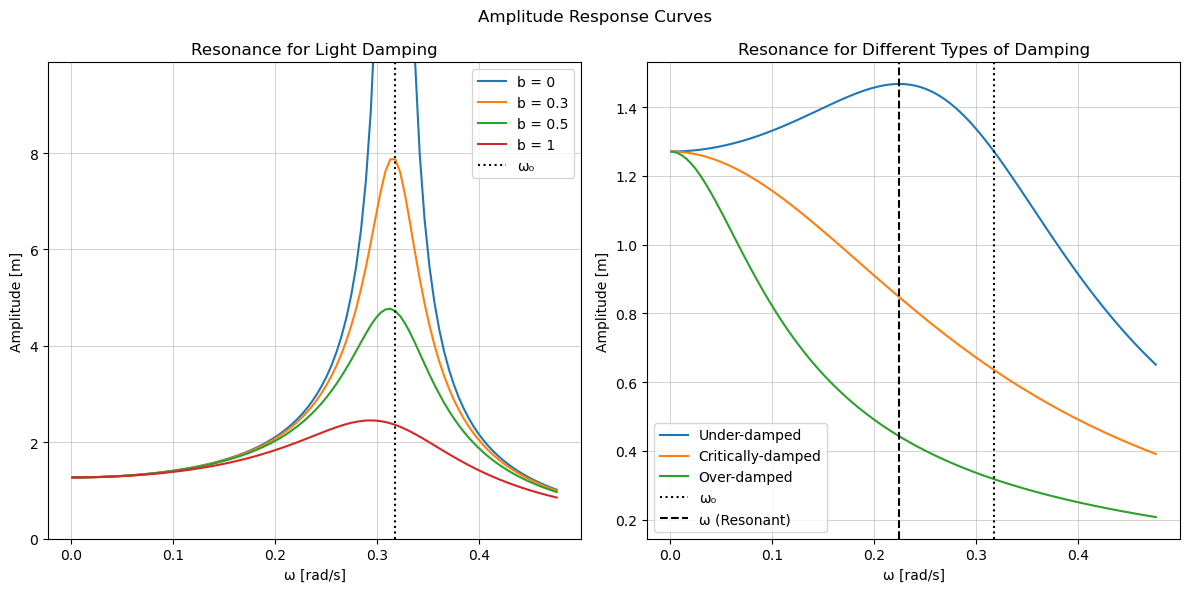

In [11]:
def max_amplitude():
    'Finds the maximum amplitude for setting limits of the graph.'

    gamma = 0.3 / m

    numerator = F_0 / m
    denominator = gamma * np.sqrt(omega_0**2 - gamma**2 / 4)

    amplitude = numerator / denominator
    
    return amplitude

def resonance_plot():

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))

    ax2.plot(omega_amp, amplitude_Response(omega_amp, gamma_values[0]), label='Under-damped')
    ax2.plot(omega_amp, amplitude_Response(omega_amp, gamma_values[1]), label='Critically-damped')
    ax2.plot(omega_amp, amplitude_Response(omega_amp, gamma_values[2]), label='Over-damped')
    ax2.axvline(omega_0, linestyle=":", color='k', label="ω₀")
    ax2.axvline(omega_res, linestyle="--", color='k', label="ω (Resonant)")
    ax2.set_title('Resonance for Different Types of Damping')


    ax1.plot(omega_amp, amplitude_Response(omega_amp, 0), label='b = 0')
    ax1.plot(omega_amp, amplitude_Response(omega_amp, 0.3 / m), label='b = 0.3')
    ax1.plot(omega_amp, amplitude_Response(omega_amp, 0.5 / m), label='b = 0.5')
    ax1.plot(omega_amp, amplitude_Response(omega_amp, 1 / m), label='b = 1')
    ax1.axvline(omega_0, linestyle=":", color='k', label="ω₀")
    ax1.set_title('Resonance for Light Damping')
    ax1.set_ylim((0, max_amplitude() * 1.25))

    for ax in (ax1, ax2):
        ax.set_xlabel('ω [rad/s]')
        ax.set_ylabel('Amplitude [m]')
        ax.grid(linewidth=0.4)
        ax.legend()

    fig.suptitle('Amplitude Response Curves')
    plt.tight_layout()
    plt.show()

omega_amp = np.linspace(0.001, 1.5 * omega_0, 100)

resonance_plot()

Considering the amplitude response on the left-hand plot (all for light damping), we can see that $A(\omega) \rightarrow \infty$ as $\omega \rightarrow \omega_0$, which follows from the equation above. This phenomenon of rapidly increasing amplitude is called resonance. But why does the peak shift to the left as damping increases? In order to maximise the amplitude, we must minimise the denominator of the response function:

$$\frac {d}{d\omega} \sqrt{(\omega_0^2 - \omega^2)^2 + \omega^2\gamma^2}=0.$$

From this, we find the resonant frequency to be

$$\omega_{res} = \sqrt{\omega_0^2-\frac{\gamma^2}{2}}.$$

As $\gamma$ is always positive, the $\omega_{res}$ will decrease with increased damping, hence the curve shifts leftwards. This explains why our under-damped resonance curve on the right-hand plot peaks so far before the natural frequency, our value for is given by $b \approx 1.86$.

Naturally, critical and over-damped systems show no oscillations, so have no resonance peak, but all three systems tend to the same values. At $\omega = 0$, we can see that the maximum amplitude is given by $A(0) = \frac{F_0}{k}$, regardless of the damping. But what about the upper limit? Again, all systems tend to the same value, as $\omega \rightarrow \infty, \: A(\omega) \rightarrow 0$, though this decay in amplitude occurs at a much greater rate for greater damping.

When discussing resonance, it's important to consider the purpose of our system. Will resonance be useful, like in a musical instrument such as a guitar? Or is it potentially harmful, like in a bridge or skyscraper? As alluded to previously, damping is often used in structures in order to minimise the effects of unwanted oscillations. A good example of negative resonant effects is the Millennium Bridge in London, which was closed for a further two years on its day of opening, due to people's footsteps causing the bridge to wobble dangerously. Mass dampers are also incredibly interesting, such as the one used in Taipei 101 to minimise the effects of strong winds. In cases such as these, critical damping is implemented by engineers to return the system to equilibrium as fast as possible. Two YouTube videos have been embedded below to illustrate this further.

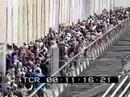

In [12]:
# Youtube video of Millennium (may not play in some environments)

YouTubeVideo('eAXVa__XWZ8')


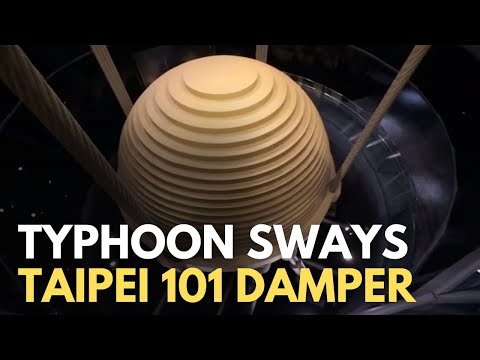

In [13]:
# Youtube video of Teipei 101 damper (may not play in some environments)

YouTubeVideo('YPEo57AjXv8')

## Total energy and dissipation
Early on in this report, we established that Cromer's method is an energy-conserving integrator. When we considered our push, we also discussed how the timing of the push affects the total energy of the system. But how does the total energy of the system change in all of our cases considered? The total energy of an oscillating mass on a spring can be found by summing the kinetic and elastic potential energy of the system, with the gravitational potential staying constant as the system oscillates horizontally. We can plot how the total energy varies with time.

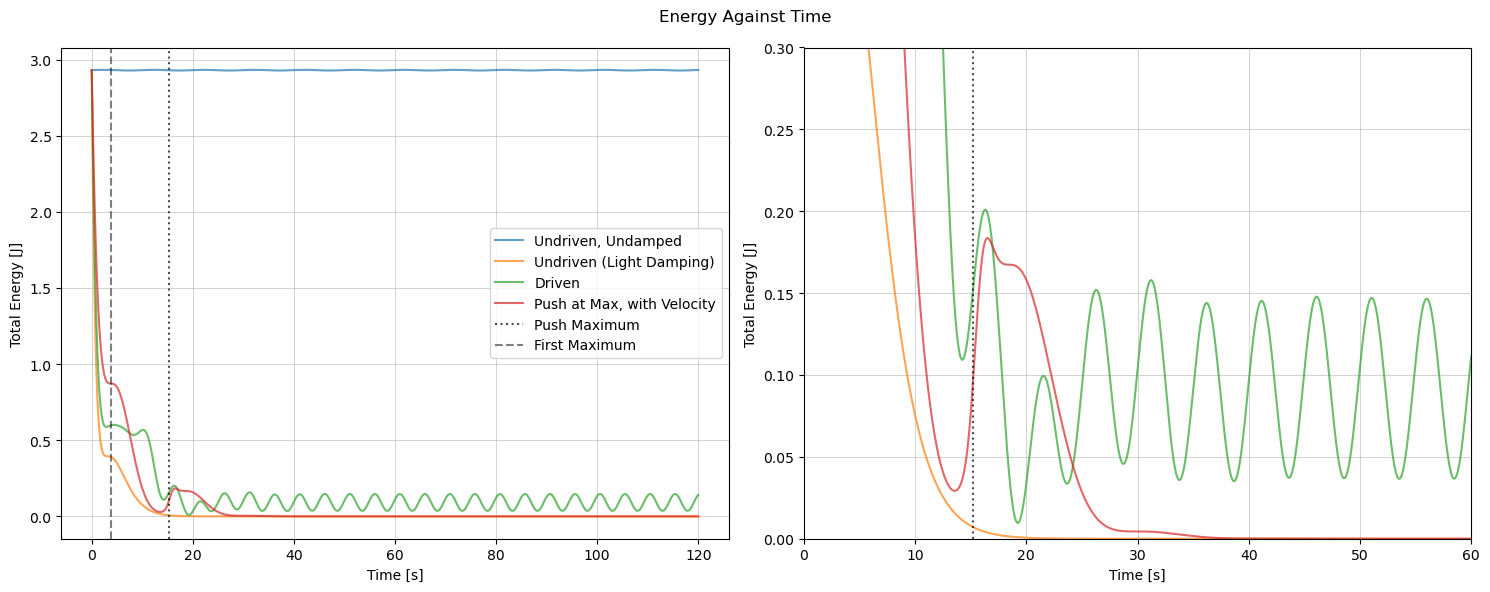

In [14]:
# Customisable limits for the right-hand plot. Defaults in x and y are 60 and 0.3 respectively

X_LIMIT = 60
Y_LIMIT = 0.3

def energy_calculation(x, v):
    'Calculates the kinetic and elastic potential energy at a point in time and adds them to find the total.'
    
    kinetic = 0.5 * m * v**2
    elastic = 0.5 * k * x**2
    
    return kinetic + elastic

x_undriven, v_undriven = cromer(h, steps, 0)
x_undriven_damp, v_undriven_damp = cromer(h, steps, b_values[1])
x_driven, v_driven = cromer_driven(steps, F_0, gamma_values[0], omega_driven)
x_inc, v_inc = cromer_push(steps, 1, gamma_values[0], light_max_index)

cases = [("Undriven, Undamped", x_undriven, v_undriven), ("Undriven (Light Damping)", x_undriven_damp, v_undriven_damp), ("Driven", x_driven, v_driven),
    ("Push at Max, with Velocity", x_inc, v_inc)]

# Plots the energy of each case with its lable

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))

for name, x, v in cases:
    energy = energy_calculation(x, v)
    ax1.plot(t, energy, label=name, alpha=0.7)
    ax2.plot(t, energy, label=name, alpha=0.7)

ax1.axvline(light_max_index * h, color='k', linestyle=':', alpha=0.7, label='Push Maximum')
ax1.axvline(np.argmin(disp_values_light)*h, color='k', linestyle='--', alpha=0.5, label='First Maximum')
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Total Energy [J]')
ax1.grid(linewidth=0.4)
ax1.legend()

ax2.set_ylim(0, Y_LIMIT)
ax2.set_xlim(0, X_LIMIT)
ax2.grid(linewidth=0.4)
ax2.axvline(light_max_index * h, color='k', linestyle=':', alpha=0.7, label='Push Maximum')
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Total Energy [J]')

fig.suptitle('Energy Against Time')
plt.tight_layout()
plt.show()

**Undriven, Undamped**: In this case, the energy remains at a constant value, as expected.

**Undriven, Lightly Damped**: The energy decreases smoothly, with a small kink at the first displacement maximum, as the energy removed due to the damping force ($F_{damping} = bv$) becomes zero at zero velocity.

**Driven**: Again, the energy decreases, but begins to show erratic behaviour due to transients. The initial drop in energy isn't as large as for the previous case, as the driving force adds energy to the system. After the system settles into the steady-state condition, the curve oscillates as energy is repeatedly added and removed from the system due to driving and damping, respectively.

**Sudden Push**: When a sudden push is applied in the direction of the velocity, at the second maximum, the initial part of the graph is similar to the two previous. As the push force begins to increase (recall, the force follows a Gaussian distribution and is centred at the maximum), the energy of the system also increases. The push force quickly decreases back down to a negligible value, and the curve once again decays as damping removes energy from the system.